# **CycleGAN Inference Script**

This script performs **inference with our fine-tunned CycleGAN generator** on images stored in a folder. It loads the first `N` images, applies the generator, and displays the results in a **grid layout**.

## Key Features

1. **Generator Setup**
   - Loads a CycleGAN generator in inference mode (`eval`) on CPU or GPU.
   - Generator weights are provided via a `.pth` file.

2. **Image Preprocessing**
   - Reads images using OpenCV and converts BGR to RGB.
   - Resizes images to the expected input size (e.g., `256x256`).
   - Normalizes pixel values to the `[-1, 1]` range for the model.

3. **Inference**
   - Passes each image through the generator to produce transformed outputs.
   - Converts the output tensor back to standard image format `[0, 255]`.

4. **Visualization**
   - Displays the first `N` predicted images in a **3x5 grid**.


## Usage
- Set the `folder_path` to your test images directory.
- Provide the path to the pre-trained generator weights.
- Adjust `num_images`, `grid_rows`, and `grid_cols`.

In [52]:
!git clone https://github.com/denisevaldivia/Disney_GAN.git
import os
os.chdir('Disney_GAN')

Cloning into 'Disney_GAN'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 88 (delta 24), reused 38 (delta 13), pack-reused 32 (from 1)
Receiving objects: 100% (88/88), 41.42 MiB | 10.62 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [58]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [59]:
import zipfile

# We extract our images from Drive
zip_path = "/content/drive/MyDrive/GAN/dataset_GAN_smooth.zip"
extract_path = "/content/dataset_gan"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")

Dataset extracted


Loading weights from /content/Cycle_gan_final.pth


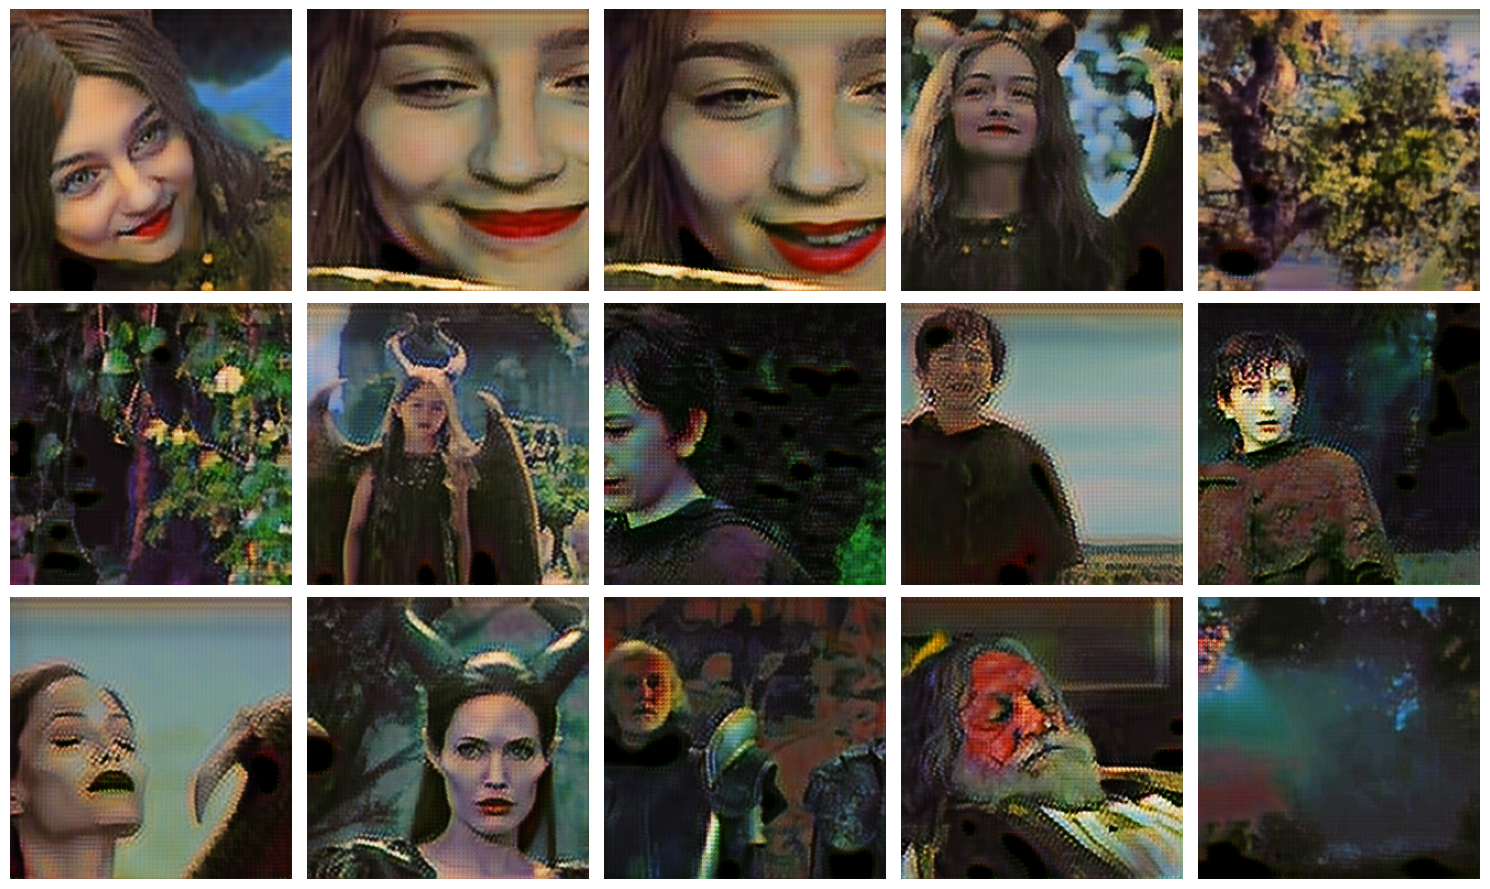

In [ ]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
from src.models.CycleGAN_Generator import define_G_inference

# Global settings
folder_path = "/content/dataset_gan/test/live_action"  # folder with images
start = 0
num_images = 15
grid_rows, grid_cols = 3, 5

# Load generator for inference
device = "cuda" if torch.cuda.is_available() else "cpu"

gen = define_G_inference(3, 3, 64, "resnet_9blocks", weights_path="notebooks/Cycle_gan_final.pth")
gen.to(device)
gen.eval()

# Same processing as CycleGan
def preprocess_image(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    tensor = torch.from_numpy(img).float().permute(2,0,1).unsqueeze(0)
    tensor = (tensor / 127.5) - 1.0  # normalize [-1,1]
    return tensor.to(device)

# Helper to undo the processing
def postprocess_tensor(tensor):
    img = ((tensor.squeeze(0).permute(1,2,0) + 1) * 127.5).clamp(0,255).byte().cpu().numpy()
    return img

# Load the first N images
image_files = sorted([os.path.join(folder_path, f)
                      for f in os.listdir(folder_path)
                      if f.lower().endswith(('.png','.jpg','.jpeg'))])[start:num_images]

# Inference
pred_images = []
for path in image_files:
    with torch.no_grad():
        input_tensor = preprocess_image(path)
        output_tensor = gen(input_tensor)
        pred_img = postprocess_tensor(output_tensor)
        pred_images.append(pred_img)

# Plot them
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(15,9))
axes = axes.flatten()
for ax, img in zip(axes, pred_images):
    ax.imshow(img)
    ax.axis("off")

# If less than grid size, hide remaining axes
for ax in axes[len(pred_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()